# Exploratory Data Analysis — Room 4.9

This notebook presents the exploratory data analysis (EDA) of the final integrated dataset for Room 4.9.

The analysis includes dataset validation, descriptive statistics, indoor air quality characteristics, desk occupancy patterns, window states, temporal behavior, and relationships among the main environmental and occupancy-related variables.

In [1]:
# IMPORTS AND NOTEBOOK CONFIGURATION


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot configuration
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# Pandas display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [2]:
# HELPER FUNCTION — DESCRIPTIVE STATISTICS


def print_statistics(series, decimals=2):
    """
    Display descriptive statistics using a consistent
    number of decimal places.
    """

    stats = series.describe().round(decimals)

    print(stats)
    print()

    print(f"Median   : {series.median():.{decimals}f}")
    print(f"Variance : {series.var():.{decimals}f}")
    print(f"Skewness : {series.skew():.{decimals}f}")

In [3]:
# LOAD DATASET


df = pd.read_csv("room_4_9_full_dataset.csv")

# Convert timestamp column to datetime
df["ts"] = pd.to_datetime(df["ts"])

print("Dataset loaded successfully!")
print()
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!

Rows: 38692
Columns: 59


,ts,co2_iaq1,temperature_iaq1,humidity_iaq1,light_level_iaq1,pir_iaq1,co2_iaq2,temperature_iaq2,humidity_iaq2,light_level_iaq2,pir_iaq2,co2_avg,temperature_avg,humidity_avg,light_level_avg,pir_any,available_iaq_sensors,desk_1,desk_2,desk_3,desk_4,desk_5,desk_6,desk_7,desk_8,desk_9,desk_10,desk_11,desk_12,desk_13,desk_14,desk_15,desk_16,desk_17,desk_18,desk_19,desk_20,desk_21,desk_22,desk_23,desk_24,desk_25,desk_26,desk_27,desk_28,desk_29,desk_30,desk_31,desk_32,occupied_desks,free_desks,occupancy_rate,any_desk_occupied,mc_1,mc_2,mc_3,mc_4,open_windows,open_windows_binary
0,2025-09-01 20:40:00,583.0,29.3,42.5,0.0,0.0,577.0,29.2,42.5,0.0,0.0,580.0,29.25,42.50,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
1,2025-09-01 20:50:00,580.0,29.3,42.5,0.0,0.0,575.0,29.2,42.5,0.0,0.0,577.5,29.25,42.50,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
2,2025-09-01 21:00:00,577.0,29.3,42.5,0.0,0.0,571.0,29.2,42.5,0.0,0.0,574.0,29.25,42.50,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
3,2025-09-01 21:10:00,572.0,29.3,42.5,0.0,0.0,566.0,29.2,43.0,0.0,0.0,569.0,29.25,42.75,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
4,2025-09-01 21:20:00,568.0,29.3,42.5,0.0,0.0,561.0,29.2,43.0,0.0,0.0,564.5,29.25,42.75,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1


## Dataset Overview and Data Quality

This section provides an overview of the final integrated dataset for Room 4.9 and verifies its basic structure, temporal coverage, and data quality.

In [4]:
# DATASET OVERVIEW

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nRows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMemory usage:")
print(
    round(
        df.memory_usage(deep=True).sum() / (1024 ** 2),
        2
    ),
    "MB"
)

print("\nTime coverage:")
print("Start :", df["ts"].min())
print("End   :", df["ts"].max())

print("\nUnique timestamps:")
print(df["ts"].nunique())

DATASET OVERVIEW

Rows: 38692
Columns: 59

Column names:
['ts', 'co2_iaq1', 'temperature_iaq1', 'humidity_iaq1', 'light_level_iaq1', 'pir_iaq1', 'co2_iaq2', 'temperature_iaq2', 'humidity_iaq2', 'light_level_iaq2', 'pir_iaq2', 'co2_avg', 'temperature_avg', 'humidity_avg', 'light_level_avg', 'pir_any', 'available_iaq_sensors', 'desk_1', 'desk_2', 'desk_3', 'desk_4', 'desk_5', 'desk_6', 'desk_7', 'desk_8', 'desk_9', 'desk_10', 'desk_11', 'desk_12', 'desk_13', 'desk_14', 'desk_15', 'desk_16', 'desk_17', 'desk_18', 'desk_19', 'desk_20', 'desk_21', 'desk_22', 'desk_23', 'desk_24', 'desk_25', 'desk_26', 'desk_27', 'desk_28', 'desk_29', 'desk_30', 'desk_31', 'desk_32', 'occupied_desks', 'free_desks', 'occupancy_rate', 'any_desk_occupied', 'mc_1', 'mc_2', 'mc_3', 'mc_4', 'open_windows', 'open_windows_binary']

Data types:
ts                       datetime64[ns]
co2_iaq1                        float64
temperature_iaq1                float64
humidity_iaq1                   float64
light_level_iaq

In [5]:
# DATA QUALITY ASSESSMENT


print("=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate timestamps:")
print(df["ts"].duplicated().sum())

primary_columns = [
    "ts",
    "co2_avg",
    "temperature_avg",
    "humidity_avg",
    "light_level_avg",
    "pir_any",
    "occupied_desks",
    "free_desks",
    "occupancy_rate",
    "any_desk_occupied",
    "open_windows",
    "open_windows_binary"
]

print("\nMissing values in primary analysis variables:")
print(df[primary_columns].isna().sum())

print("\nAvailable IAQ sensors:")
print(df["available_iaq_sensors"].value_counts().sort_index())

print("\nUnique occupied desk values:")
print(sorted(df["occupied_desks"].unique()))

print("\nUnique open-window values:")
print(sorted(df["open_windows"].unique()))

DATA QUALITY ASSESSMENT

Duplicate rows:
0

Duplicate timestamps:
0

Missing values in primary analysis variables:
ts                     0
co2_avg                0
temperature_avg        0
humidity_avg           0
light_level_avg        0
pir_any                0
occupied_desks         0
free_desks             0
occupancy_rate         0
any_desk_occupied      0
open_windows           0
open_windows_binary    0
dtype: int64

Available IAQ sensors:
available_iaq_sensors
1     1777
2    36915
Name: count, dtype: int64

Unique occupied desk values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(

## Descriptive Statistics

This section summarizes the main environmental, desk-occupancy, and window-state variables of Room 4.9 using descriptive statistics.

In [6]:
# DESCRIPTIVE STATISTICS


features = [
    "co2_avg",
    "temperature_avg",
    "humidity_avg",
    "light_level_avg",
    "occupied_desks",
    "occupancy_rate",
    "open_windows"
]

summary = pd.DataFrame()

for col in features:
    summary.loc[col, "count"] = df[col].count()
    summary.loc[col, "mean"] = df[col].mean()
    summary.loc[col, "std"] = df[col].std()
    summary.loc[col, "min"] = df[col].min()
    summary.loc[col, "25%"] = df[col].quantile(0.25)
    summary.loc[col, "50%"] = df[col].median()
    summary.loc[col, "75%"] = df[col].quantile(0.75)
    summary.loc[col, "max"] = df[col].max()
    summary.loc[col, "variance"] = df[col].var()
    summary.loc[col, "skewness"] = df[col].skew()

display(summary.round(2))

,count,mean,std,min,25%,50%,75%,max,variance,skewness
co2_avg,38692.0,518.51,219.03,368.00,418.5,452.00,517.50,3889.00,47975.17,4.91
temperature_avg,38692.0,22.84,2.49,18.20,20.8,22.55,24.40,30.40,6.21,0.64
humidity_avg,38692.0,44.63,6.01,27.75,40.5,44.00,48.75,65.75,36.07,0.29
light_level_avg,38692.0,0.38,0.74,0.00,0.0,0.00,0.50,3.00,0.55,1.79
occupied_desks,38692.0,1.34,4.63,0.00,0.0,0.00,0.00,32.00,21.47,4.22
occupancy_rate,38692.0,0.04,0.14,0.00,0.0,0.00,0.00,1.00,0.02,4.22
open_windows,38692.0,1.93,0.95,0.00,1.0,2.00,3.00,4.00,0.90,0.58


## Indoor Air Quality Analysis

The following analysis examines the distribution and characteristics of indoor CO₂ concentration in Room 4.9.

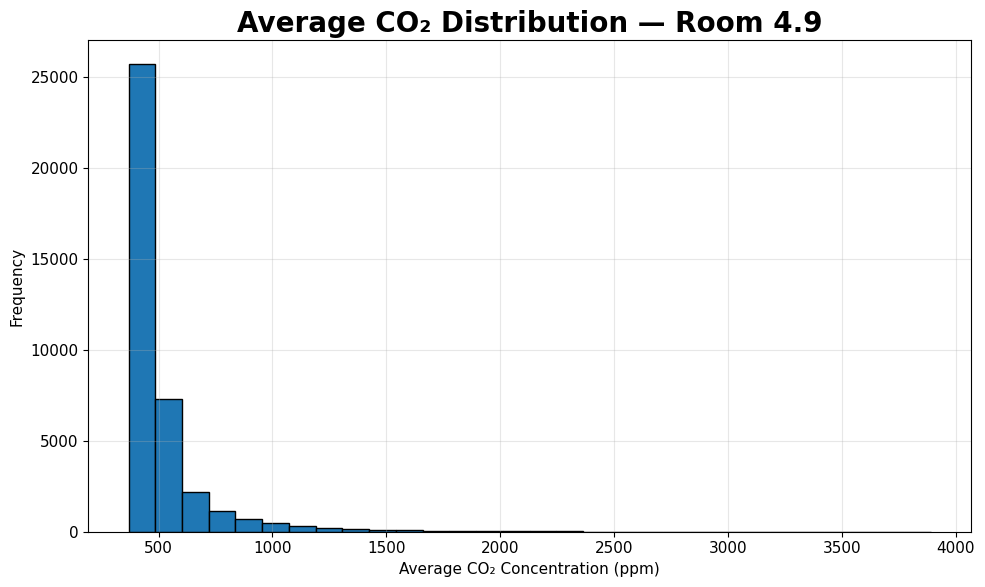

count    38692.00
mean       518.51
std        219.03
min        368.00
25%        418.50
50%        452.00
75%        517.50
max       3889.00
Name: co2_avg, dtype: float64

Median   : 452.00
Variance : 47975.17
Skewness : 4.91
Saved: Figure_4_1_CO2_Distribution_Room_4_9.png


In [7]:
# FIGURE 4.1 — CO₂ DISTRIBUTION


fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df["co2_avg"],
    bins=30,
    edgecolor="black"
)

ax.set_title(
    "Average CO₂ Distribution — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Average CO₂ Concentration (ppm)")
ax.set_ylabel("Frequency")
ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_4_1_CO2_Distribution_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print_statistics(df["co2_avg"])

print(f"Saved: {file_name}")

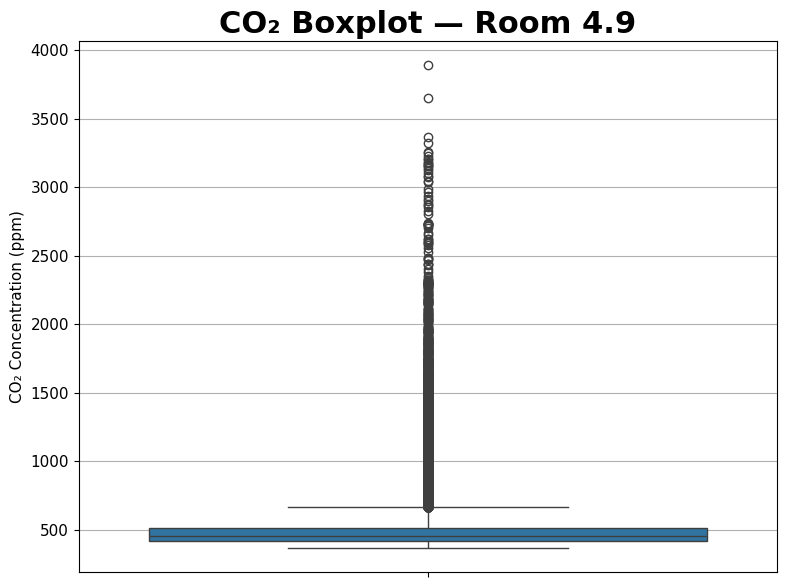

Saved: Figure_4_2_CO2_Boxplot_Lab_4_9.png


In [8]:
# ADDITIONAL ANALYSIS — CO₂ BOXPLOT


fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    y=df["co2_avg"],
    ax=ax
)

ax.set_title(
    "CO₂ Boxplot — Room 4.9",
    fontsize=22,
    weight="bold"
)

ax.set_ylabel("CO₂ Concentration (ppm)")

plt.tight_layout()

file_name = "Figure_4_2_CO2_Boxplot_Lab_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

## Desk Occupancy Analysis

This section examines the distribution and temporal characteristics of desk occupancy in Room 4.9.

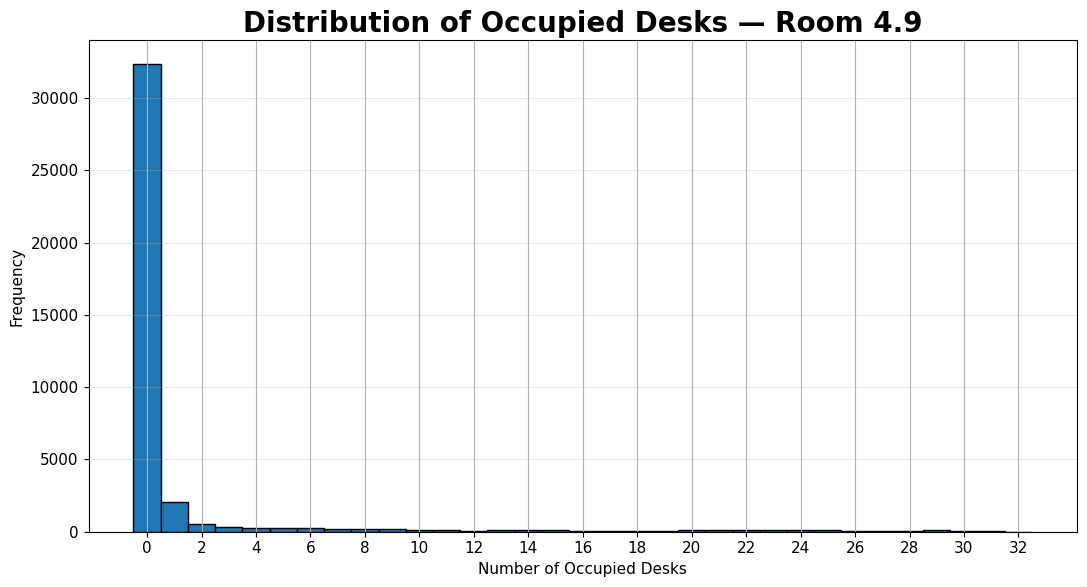

count    38692.00
mean         1.34
std          4.63
min          0.00
25%          0.00
50%          0.00
75%          0.00
max         32.00
Name: occupied_desks, dtype: float64

Median   : 0.00
Variance : 21.47
Skewness : 4.22
Saved: Figure_4_2_Occupied_Desks_Distribution_Room_4_9.png


In [9]:
# FIGURE 4.2 — OCCUPIED DESKS DISTRIBUTION

fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    df["occupied_desks"],
    bins=np.arange(-0.5, 33.5, 1),
    edgecolor="black"
)

ax.set_title(
    "Distribution of Occupied Desks — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Number of Occupied Desks")
ax.set_ylabel("Frequency")
ax.set_xticks(range(0, 33, 2))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_4_2_Occupied_Desks_Distribution_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print_statistics(df["occupied_desks"])

print(f"Saved: {file_name}")

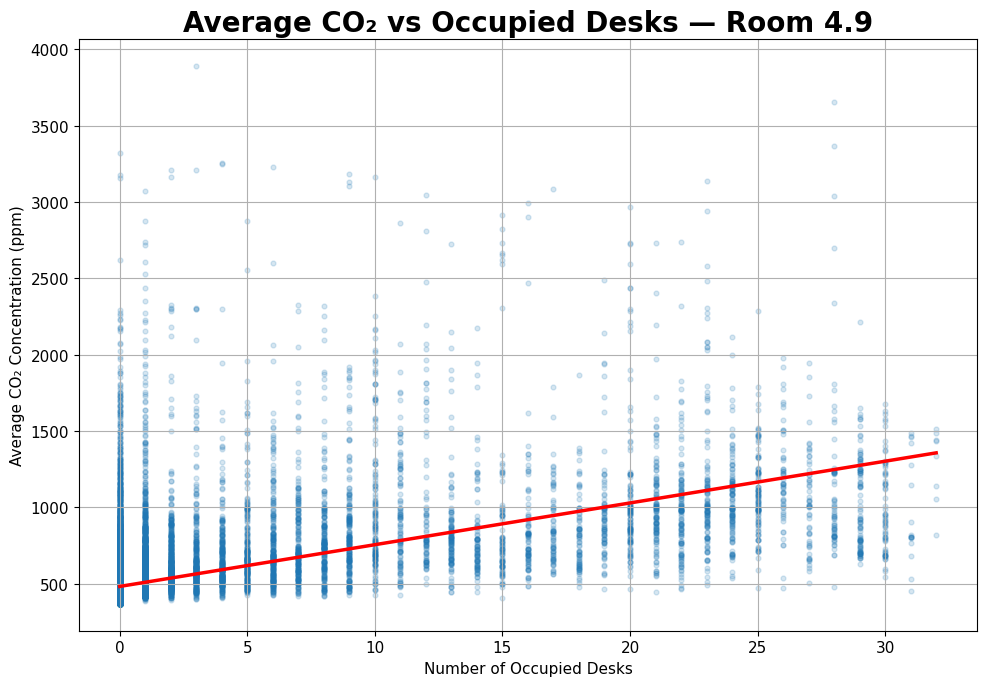

Saved: Figure_4_3_CO2_vs_Occupied_Desks_Room_4_9.png


In [10]:
# FIGURE 4.3 — CO₂ VS OCCUPIED DESKS


fig, ax = plt.subplots(figsize=(10, 7))

sns.regplot(
    data=df,
    x="occupied_desks",
    y="co2_avg",
    scatter_kws={
        "alpha": 0.18,
        "s": 12
    },
    line_kws={
        "color": "red",
        "linewidth": 2.5
    },
    ci=None,
    ax=ax
)

ax.set_title(
    "Average CO₂ vs Occupied Desks — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Number of Occupied Desks")
ax.set_ylabel("Average CO₂ Concentration (ppm)")

plt.tight_layout()

file_name = "Figure_4_3_CO2_vs_Occupied_Desks_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

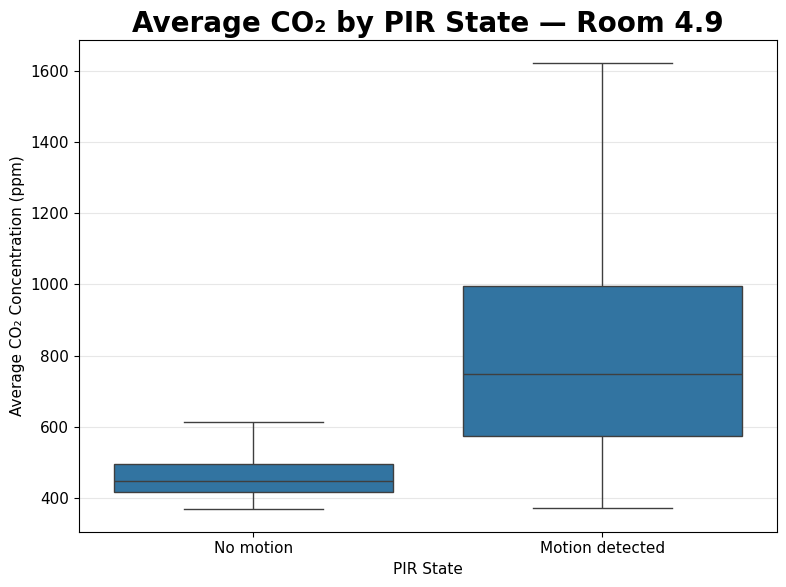

Saved: Figure_4_4_CO2_by_PIR_State_Room_4_9.png


In [11]:
# FIGURE 4.4 — CO₂ BY PIR STATE


pir_labels = {
    0: "No motion",
    1: "Motion detected"
}

df["pir_label"] = df["pir_any"].map(pir_labels)

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="pir_label",
    y="co2_avg",
    order=["No motion", "Motion detected"],
    showfliers=False,
    ax=ax
)

ax.set_title(
    "Average CO₂ by PIR State — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("PIR State")
ax.set_ylabel("Average CO₂ Concentration (ppm)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_4_4_CO2_by_PIR_State_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

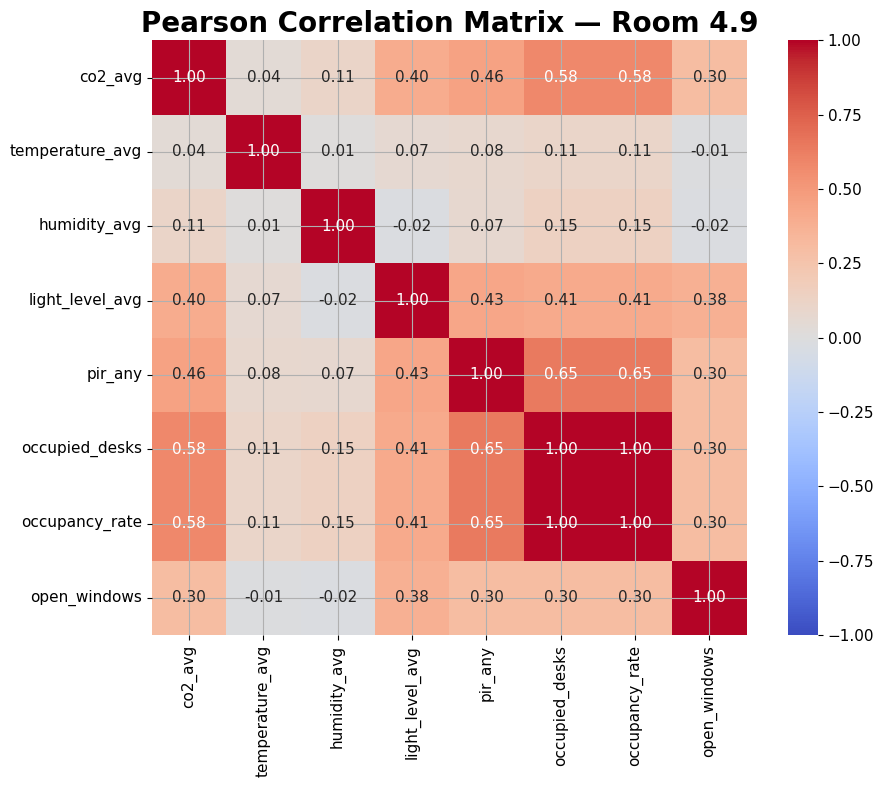

Saved: Figure_4_5_Pearson_Correlation_Matrix_Room_4_9.png


In [12]:
# FIGURE 4.5 — PEARSON CORRELATION MATRIX


correlation_features = [
    "co2_avg",
    "temperature_avg",
    "humidity_avg",
    "light_level_avg",
    "pir_any",
    "occupied_desks",
    "occupancy_rate",
    "open_windows"
]

corr_4_9 = df[correlation_features].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_4_9,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax
)

ax.set_title(
    "Pearson Correlation Matrix — Room 4.9",
    fontsize=20,
    weight="bold"
)

plt.tight_layout()

file_name = "Figure_4_5_Pearson_Correlation_Matrix_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

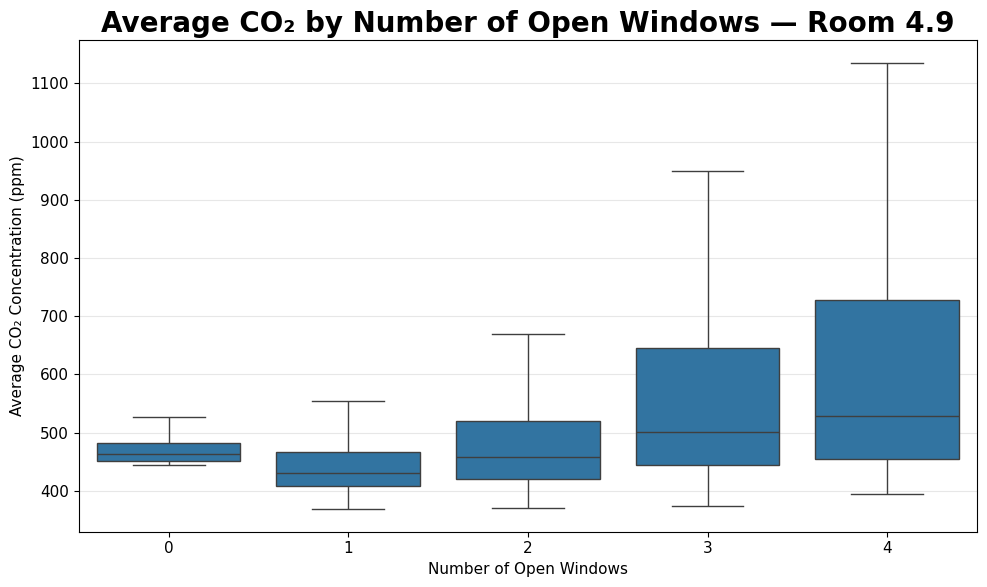

Saved: Figure_4_6_CO2_by_Open_Windows_Room_4_9.png


In [13]:
# FIGURE 4.6 — CO₂ BY NUMBER OF OPEN WINDOWS


fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="open_windows",
    y="co2_avg",
    showfliers=False,
    ax=ax
)

ax.set_title(
    "Average CO₂ by Number of Open Windows — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Number of Open Windows")
ax.set_ylabel("Average CO₂ Concentration (ppm)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_4_6_CO2_by_Open_Windows_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

## Temporal Analysis

This section examines temporal patterns in desk occupancy and indoor CO₂ concentration in Room 4.9.

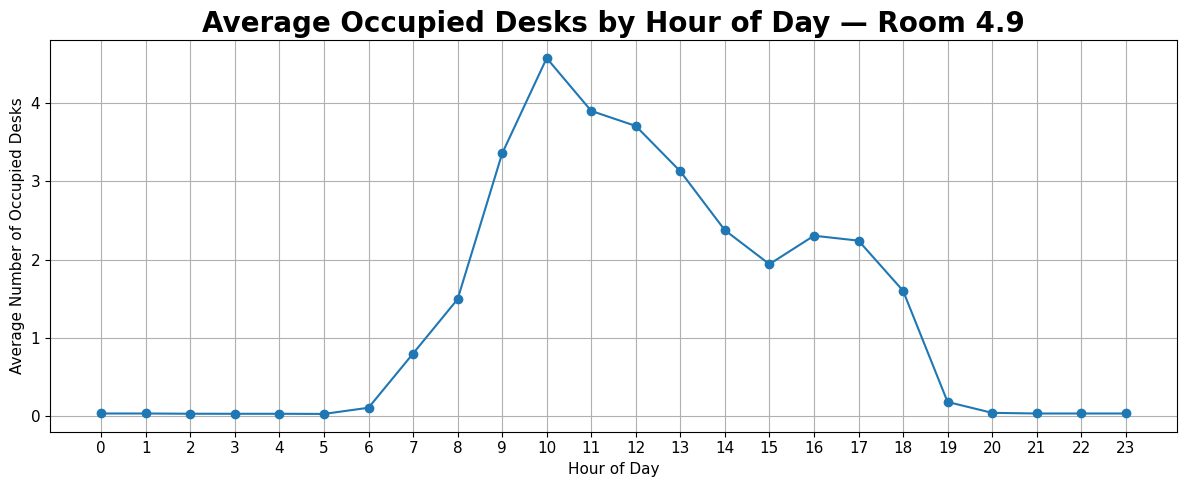

Saved: Figure_4_7_Hourly_Occupied_Desks_Room_4_9.png


In [14]:
# FIGURE 4.7 — AVERAGE OCCUPIED DESKS BY HOUR


# Create hour feature for temporal analysis
df["hour"] = df["ts"].dt.hour

hourly_occupancy = (
    df.groupby("hour")["occupied_desks"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    hourly_occupancy["hour"],
    hourly_occupancy["occupied_desks"],
    marker="o"
)

ax.set_title(
    "Average Occupied Desks by Hour of Day — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Number of Occupied Desks")
ax.set_xticks(range(24))

plt.tight_layout()

file_name = "Figure_4_7_Hourly_Occupied_Desks_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

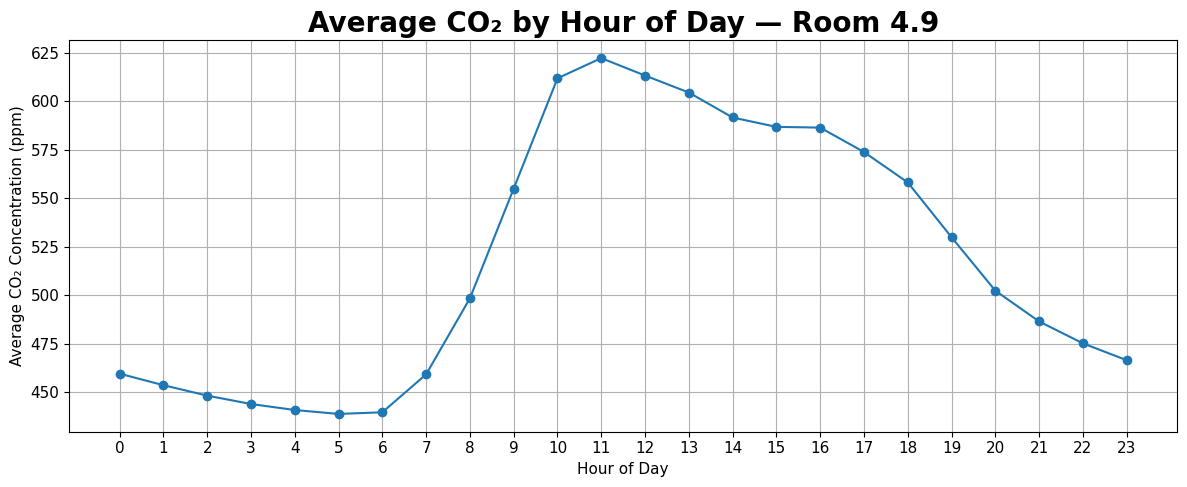

Saved: Figure_4_8_Hourly_CO2_Room_4_9.png


In [15]:
# FIGURE 4.8 — AVERAGE CO₂ BY HOUR


hourly_co2 = (
    df.groupby("hour")["co2_avg"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    hourly_co2["hour"],
    hourly_co2["co2_avg"],
    marker="o"
)

ax.set_title(
    "Average CO₂ by Hour of Day — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average CO₂ Concentration (ppm)")
ax.set_xticks(range(24))

plt.tight_layout()

file_name = "Figure_4_8_Hourly_CO2_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

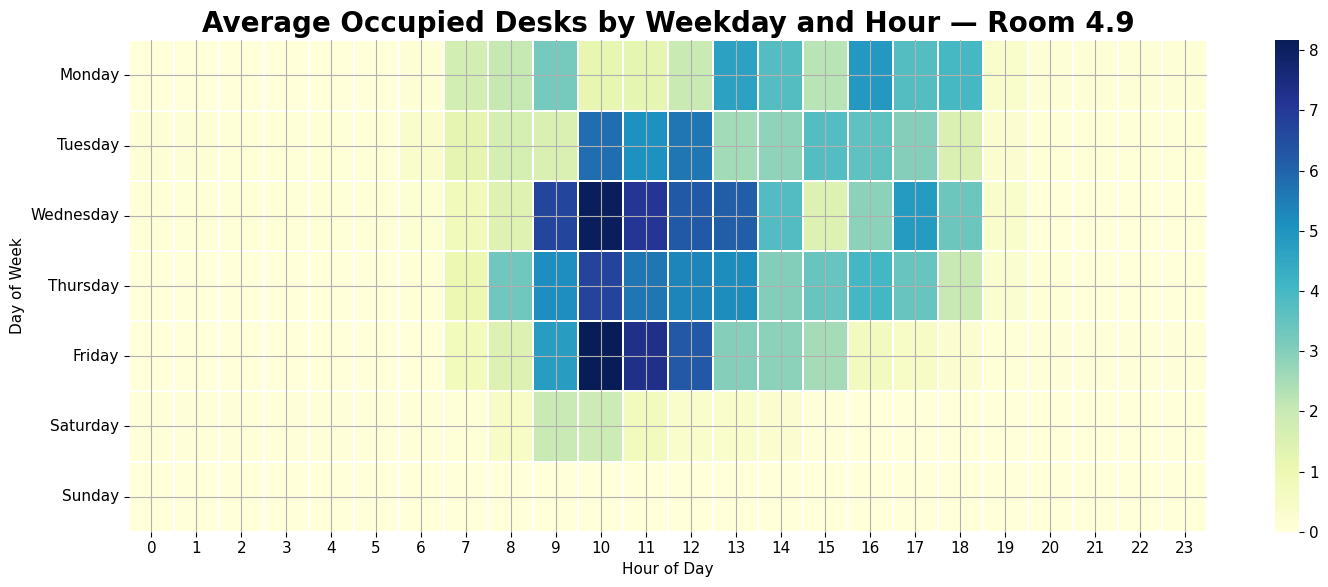

Saved: Figure_4_9_Occupancy_Heatmap_Room_4_9.png


In [16]:
# FIGURE 4.9 — OCCUPANCY HEATMAP


# Create weekday feature for temporal analysis
df["weekday"] = df["ts"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

occupancy_heatmap = (
    df.pivot_table(
        values="occupied_desks",
        index="weekday",
        columns="hour",
        aggfunc="mean"
    )
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(15, 6))

sns.heatmap(
    occupancy_heatmap,
    cmap="YlGnBu",
    linewidths=0.3,
    ax=ax
)

ax.set_title(
    "Average Occupied Desks by Weekday and Hour — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")

plt.tight_layout()

file_name = "Figure_4_9_Occupancy_Heatmap_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

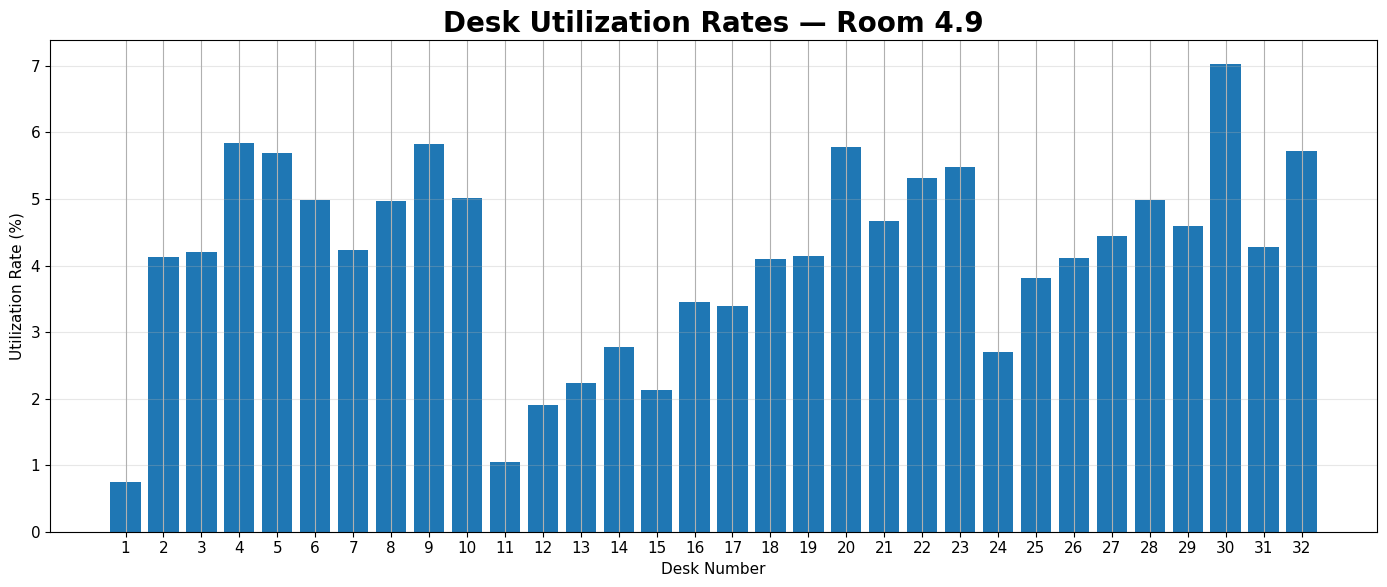

,Desk Number,Utilization (%)
0,1,0.75
1,2,4.13
2,3,4.21
3,4,5.84
4,5,5.69
5,6,4.98
6,7,4.23
7,8,4.97
8,9,5.82
9,10,5.02


Saved: Figure_4_10_Desk_Utilization_Room_4_9.png


In [17]:
# FIGURE 4.10 — DESK UTILIZATION


desk_columns = [
    f"desk_{i}"
    for i in range(1, 33)
]

desk_utilization = (
    df[desk_columns]
    .mean()
    .mul(100)
    .reset_index()
)

desk_utilization.columns = [
    "Desk",
    "Utilization (%)"
]

desk_utilization["Desk Number"] = (
    desk_utilization["Desk"]
    .str.extract(r"(\d+)")
    .astype(int)
)

desk_utilization = desk_utilization.sort_values("Desk Number")

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    desk_utilization["Desk Number"],
    desk_utilization["Utilization (%)"]
)

ax.set_title(
    "Desk Utilization Rates — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Desk Number")
ax.set_ylabel("Utilization Rate (%)")
ax.set_xticks(range(1, 33))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_4_10_Desk_Utilization_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(
    desk_utilization[
        ["Desk Number", "Utilization (%)"]
    ].round(2)
)

print(f"Saved: {file_name}")

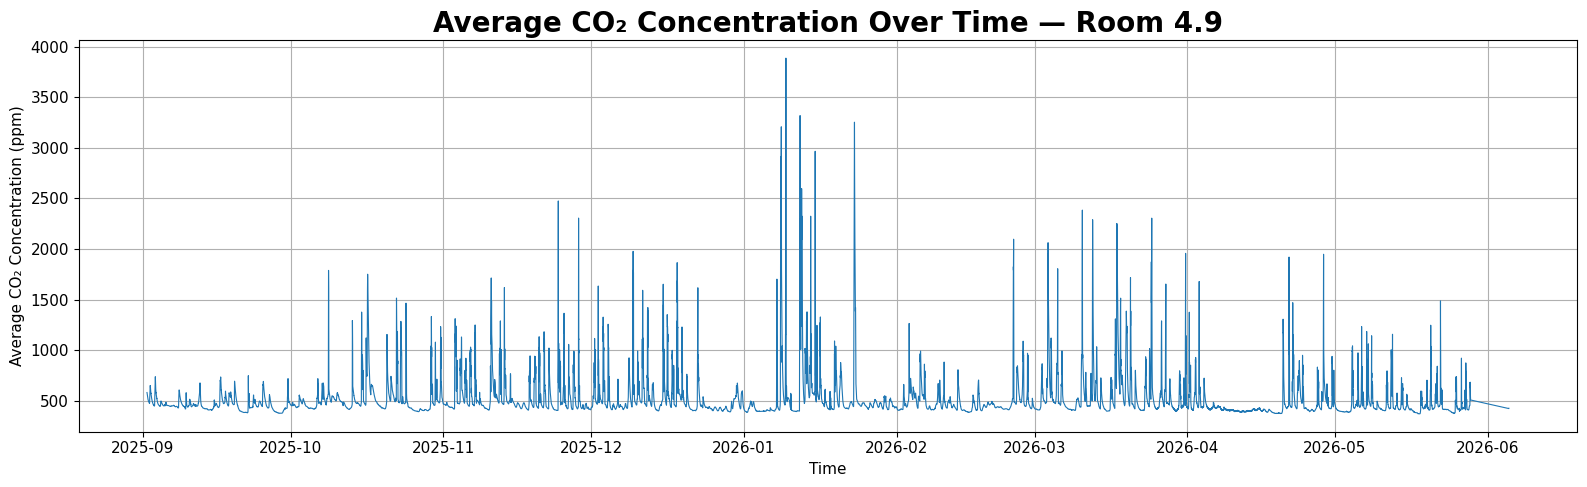

Saved: Figure_4_11_CO2_TimeSeries_Room_4_9.png


In [18]:
# FIGURE 4.11 — CO₂ CONCENTRATION OVER TIME


fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    df["ts"],
    df["co2_avg"],
    linewidth=0.8
)

ax.set_title(
    "Average CO₂ Concentration Over Time — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Time")
ax.set_ylabel("Average CO₂ Concentration (ppm)")

plt.tight_layout()

file_name = "Figure_4_11_CO2_TimeSeries_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

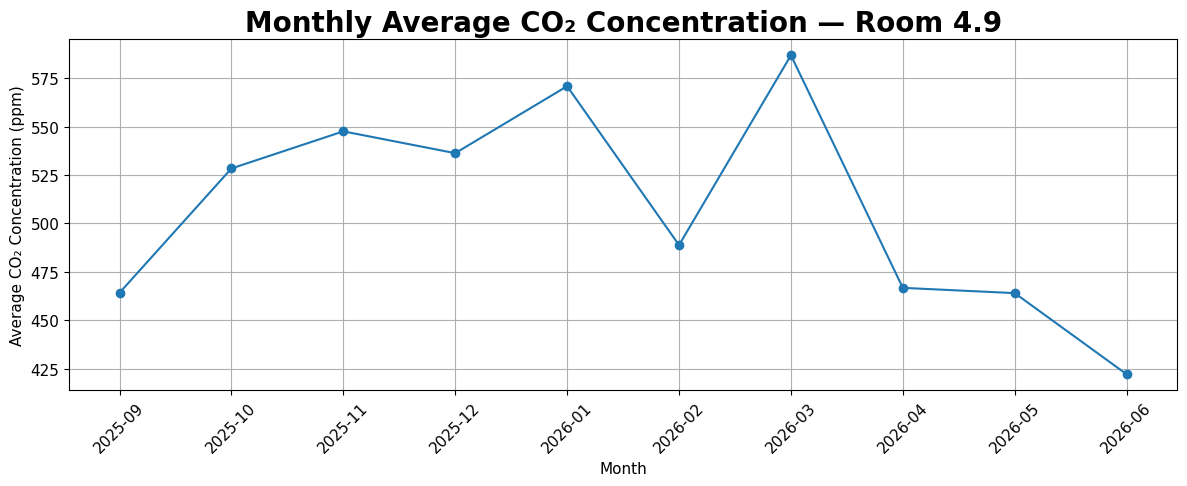

Saved: Figure_4_12_Monthly_CO2_Room_4_9.png


In [19]:
# FIGURE 4.12 — MONTHLY AVERAGE CO₂


# Create month feature for temporal analysis
df["month"] = df["ts"].dt.to_period("M").astype(str)

monthly_co2 = (
    df.groupby("month")["co2_avg"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_co2["month"],
    monthly_co2["co2_avg"],
    marker="o"
)

ax.set_title(
    "Monthly Average CO₂ Concentration — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Average CO₂ Concentration (ppm)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

file_name = "Figure_4_12_Monthly_CO2_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

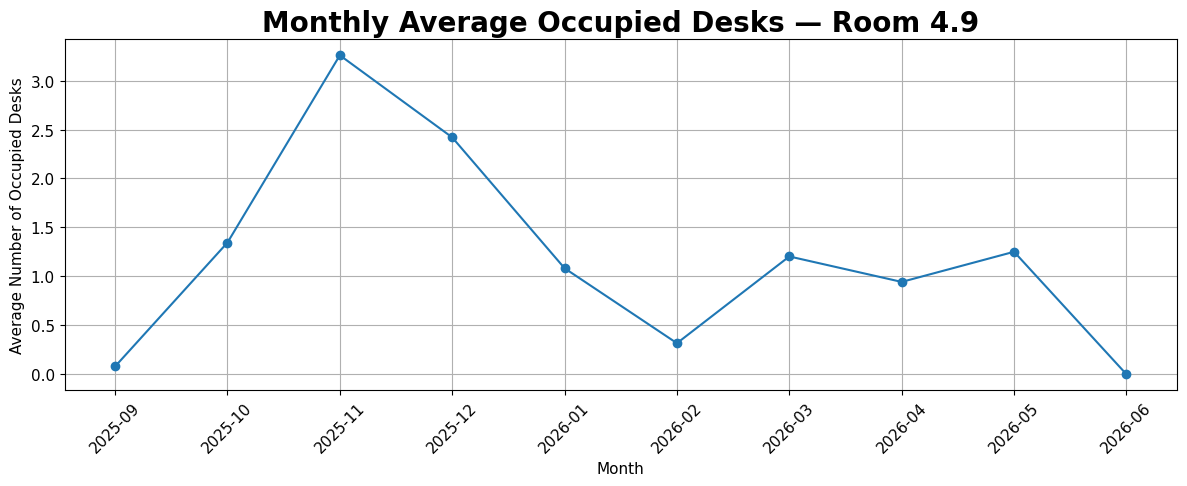

Saved: Figure_4_13_Monthly_Occupied_Desks_Room_4_9.png


In [20]:
# FIGURE 4.13 — MONTHLY AVERAGE OCCUPIED DESKS


monthly_occupancy = (
    df.groupby("month")["occupied_desks"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_occupancy["month"],
    monthly_occupancy["occupied_desks"],
    marker="o"
)

ax.set_title(
    "Monthly Average Occupied Desks — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Average Number of Occupied Desks")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

file_name = "Figure_4_13_Monthly_Occupied_Desks_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

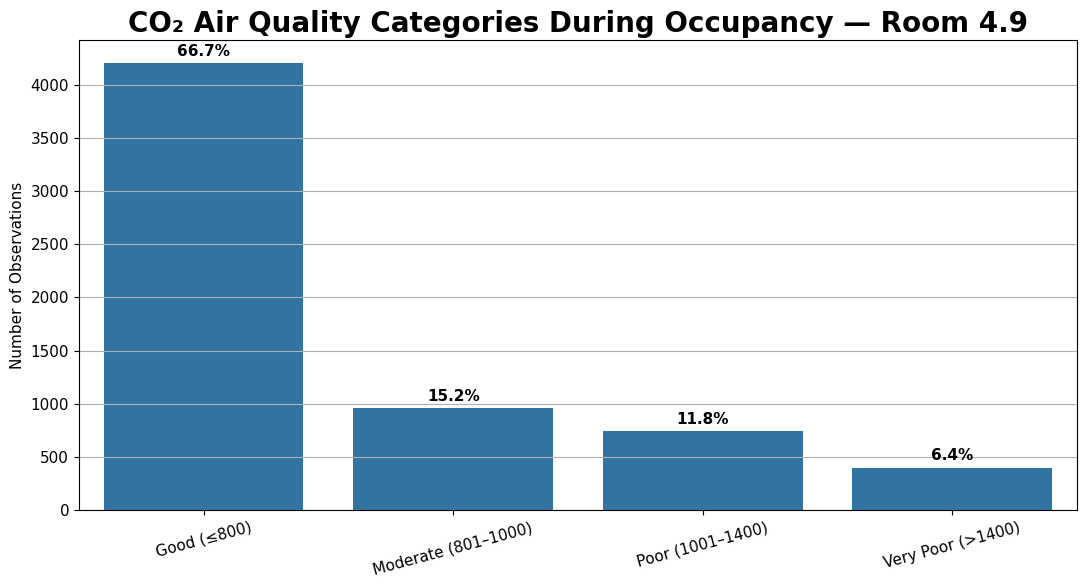

,Count,Percentage (%)
co2_category,,
Good (≤800),4206,66.72
Moderate (801–1000),956,15.16
Poor (1001–1400),741,11.75
Very Poor (>1400),401,6.36



Occupied observations: 6304
Saved: Figure_4_14_CO2_Categories_During_Occupancy_Room_4_9.png


In [21]:
# FIGURE 4.14 — CO₂ CATEGORIES DURING DESK OCCUPANCY


occupied_df = df[df["occupied_desks"] > 0].copy()

occupied_df["co2_category"] = pd.cut(
    occupied_df["co2_avg"],
    bins=[0, 800, 1000, 1400, np.inf],
    labels=[
        "Good (≤800)",
        "Moderate (801–1000)",
        "Poor (1001–1400)",
        "Very Poor (>1400)"
    ],
    include_lowest=True
)

category_counts = (
    occupied_df["co2_category"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

category_counts["Percentage (%)"] = (
    category_counts["Count"]
    / category_counts["Count"].sum()
    * 100
).round(2)

fig, ax = plt.subplots(figsize=(11, 6))

sns.countplot(
    data=occupied_df,
    x="co2_category",
    order=category_counts.index,
    ax=ax
)

ax.set_title(
    "CO₂ Air Quality Categories During Occupancy — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Number of Observations")
ax.tick_params(axis="x", rotation=15)

total = len(occupied_df)

for container in ax.containers:
    labels = [
        f"{bar.get_height() / total * 100:.1f}%"
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=11,
        weight="bold"
    )

plt.tight_layout()

file_name = "Figure_4_14_CO2_Categories_During_Occupancy_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(category_counts)

print("\nOccupied observations:", len(occupied_df))
print(f"Saved: {file_name}")

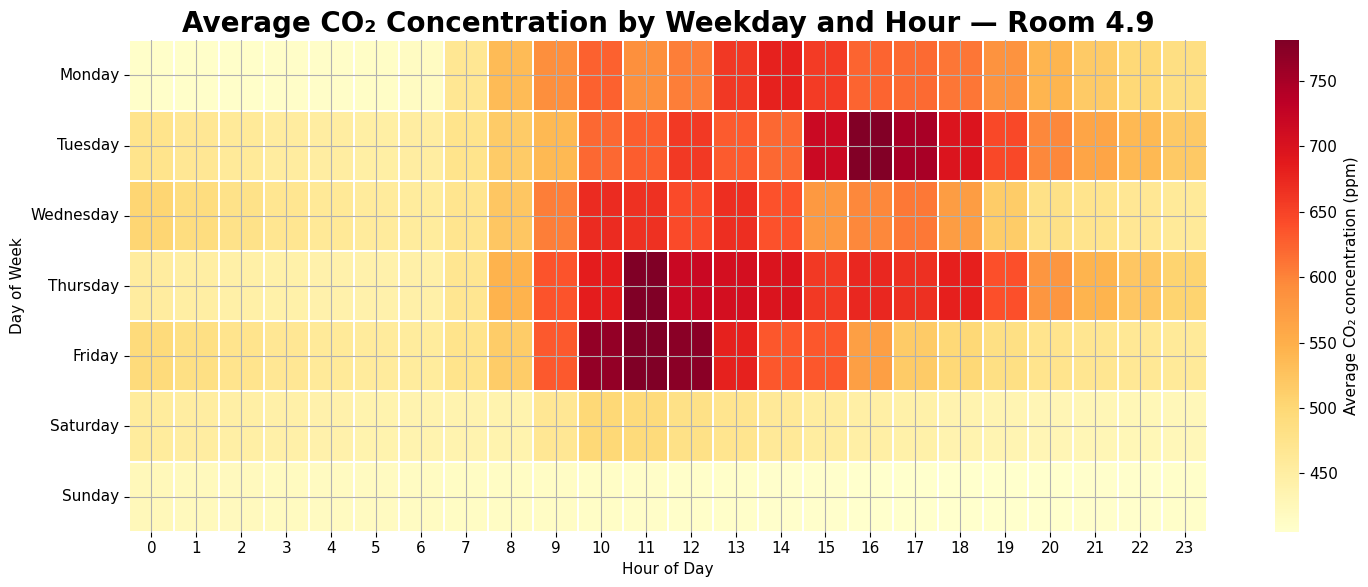

Saved: Figure_4_9_CO2_Weekday_Hour_Heatmap_Room_4_9.png


In [22]:
# ADDITIONAL ANALYSIS — CO₂ BY WEEKDAY AND HOUR


co2_heatmap = (
    df.pivot_table(
        index="weekday",
        columns="hour",
        values="co2_avg",
        aggfunc="mean"
    )
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(15, 6))

sns.heatmap(
    co2_heatmap,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.3,
    cbar_kws={
        "label": "Average CO₂ concentration (ppm)"
    },
    ax=ax
)

ax.set_title(
    "Average CO₂ Concentration by Weekday and Hour — Room 4.9",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")

plt.tight_layout()

file_name = "Figure_4_9_CO2_Weekday_Hour_Heatmap_Room_4_9.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

In [23]:
# FINAL CLEANUP AND VALIDATION

# Remove temporary columns created during EDA
temporary_columns = [
    "pir_label",
    "hour",
    "weekday",
    "month"
]

df.drop(
    columns=[
        col for col in temporary_columns
        if col in df.columns
    ],
    inplace=True
)

# Final integrity checks
assert df.shape[0] == 38692
assert df.shape[1] == 59
assert df["ts"].duplicated().sum() == 0
assert df[primary_columns].isna().sum().sum() == 0

print("=" * 60)
print("ROOM 4.9 EDA — FINAL VALIDATION")
print("=" * 60)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nTime range:")
print(df["ts"].min(), "→", df["ts"].max())

print("\nMissing values in primary variables:")
print(df[primary_columns].isna().sum())

print("\nDuplicate timestamps:")
print(df["ts"].duplicated().sum())

occupied_observations = (df["occupied_desks"] > 0).sum()

print("\nObserved desk occupancy:")
print(
    occupied_observations,
    "observations",
    f"({occupied_observations / len(df) * 100:.2f}%)"
)

above_1000 = (df["co2_avg"] > 1000).sum()

print("\nCO₂ above 1000 ppm:")
print(
    above_1000,
    "observations",
    f"({above_1000 / len(df) * 100:.2f}%)"
)

occupied_above_1000 = (
    (df["occupied_desks"] > 0)
    & (df["co2_avg"] > 1000)
).sum()

print("\nCO₂ above 1000 ppm during occupancy:")
print(
    occupied_above_1000,
    "observations",
    f"({occupied_above_1000 / occupied_observations * 100:.2f}%)"
)

print("\nRoom 4.9 EDA completed successfully.")

ROOM 4.9 EDA — FINAL VALIDATION

Rows: 38692
Columns: 59

Time range:
2025-09-01 20:40:00 → 2026-06-05 06:50:00

Missing values in primary variables:
ts                     0
co2_avg                0
temperature_avg        0
humidity_avg           0
light_level_avg        0
pir_any                0
occupied_desks         0
free_desks             0
occupancy_rate         0
any_desk_occupied      0
open_windows           0
open_windows_binary    0
dtype: int64

Duplicate timestamps:
0

Observed desk occupancy:
6304 observations (16.29%)

CO₂ above 1000 ppm:
1380 observations (3.57%)

CO₂ above 1000 ppm during occupancy:
1142 observations (18.12%)

Room 4.9 EDA completed successfully.
